# Notebook 01: Qubits and State Intuition

Prerequisite: read Chapter 01 first for the concept and definitions.

This lab is practice-first. You will apply superposition and repeated measurement after the chapter concept is clear.

## Goals
1. Create a qubit in superposition with an H gate.
2. Measure outcome distributions.
3. Apply a simple pass threshold for balance checks.

## Cell-by-cell Guide
Read this first so every cell is easy to follow.
1. Understand concept and expected result - Notebook 01: Qubits and State Intuition
2. Understand concept and expected result - Real-World Scenario
3. Run logic and inspect output - from qiskit import QuantumCircuit
4. Run logic and inspect output - qc = QuantumCircuit(1, 1)
5. Run logic and inspect output - pd.Series(counts).plot(kind="bar", title="Superposition counts (shots=1024)")
6. Run logic and inspect output - rows = []
7. Run logic and inspect output - threshold = 0.10

## Real-World Scenario
**Scenario:** Hardware Queue Budget Decision

**Problem:** You have limited cloud hardware credits and need to decide which circuits are worth running.
**Baseline:** Run simulator-first sanity checks before any hardware queue submission.
**Metric to watch:** Pass rate at threshold and decision consistency across repeats.
**Practical takeaway:** Use simulator filtering to reduce wasted hardware credits.

## Imports and Purpose
This lab uses `QuantumCircuit` to build the circuit, `AerSimulator` to run it locally, `pandas` to summarize repeated trials, and `matplotlib` to plot the counts.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pandas as pd
import matplotlib.pyplot as plt

sim = AerSimulator()

def run_counts(qc, shots=1024):
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return {"0": counts.get("0", 0), "1": counts.get("1", 0)}

In [2]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

counts = run_counts(qc, shots=1024)
counts

{'0': 499, '1': 525}

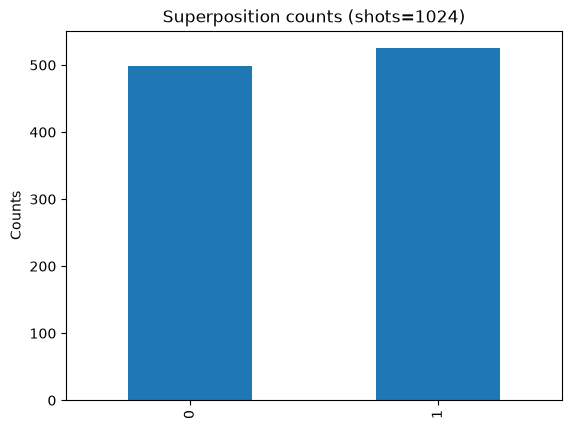

In [3]:
pd.Series(counts).plot(kind="bar", title="Superposition counts (shots=1024)")
plt.ylabel("Counts")
plt.show()

In [4]:
rows = []
for trial in range(1, 6):
    c = run_counts(qc, shots=1024)
    p0 = c["0"] / 1024
    p1 = c["1"] / 1024
    rows.append({"trial": trial, "p0": p0, "p1": p1, "abs_diff": abs(p0 - p1)})

df = pd.DataFrame(rows)
df

,trial,p0,p1,abs_diff
0,1,0.511719,0.488281,0.023438
1,2,0.525391,0.474609,0.050781
2,3,0.475586,0.524414,0.048828
3,4,0.515625,0.484375,0.031250
4,5,0.527344,0.472656,0.054688


In [5]:
threshold = 0.10
max_abs_diff = df["abs_diff"].max()
decision = "PASS" if max_abs_diff <= threshold else "INVESTIGATE"
print(f"Max |p0-p1| across runs: {max_abs_diff:.4f}")
print(f"Threshold: {threshold:.2f}")
print(f"Decision: {decision}")

Max |p0-p1| across runs: 0.0547
Threshold: 0.10
Decision: PASS
